# 05 — Experimentación del módulo MDP

Diseño del ambiente, ejecución de Value Iteration desde cero (`src/mdp/solver.py`), visualización de la política óptima como heatmap mes × nivel_roya y comparación contra cinco baselines de política constante.

**Estado:** `(mes ∈ 1..12) × (nivel_roya ∈ {0,1,2})` ⇒ 36 estados. Codificación `s = (mes-1)*3 + roya`.

**Acciones (5):** 0 nada, 1 fertilizar, 2 cobre (preventivo), 3 triazol (curativo), 4 podar.

**Reward:** ingreso bruto por cosecha (oct–feb) proporcional al rendimiento esperado del nivel de roya, menos costo de la acción, menos penalización por roya alta sin tratamiento. Parámetros en `src/mdp/environment.py`.

**Descuento:** γ = 0.95. **Convergencia:** ||V_{k+1} − V_k||∞ < 10⁻³.

In [1]:
import sys
from pathlib import Path

sys.path.insert(0, str(Path.cwd().parent))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from src.mdp.environment import (
    build_environment, validate_transitions, Parameters,
    N_STATES, N_ACTIONS, ACTION_NAMES, RUST_NAMES, MONTH_NAMES,
    state_index, decode_state, WET_MONTHS, HARVEST_MONTHS,
)
from src.mdp.solver import value_iteration, evaluate_policy, constant_policy

params = Parameters()
T, R = build_environment(params)
validate_transitions(T)
T.shape, R.shape

((36, 5, 36), (36, 5))

## 1. Validación del ambiente

Toda fila de `T[s, a, ·]` debe sumar 1 (distribución de probabilidad sobre estados siguientes). Verificación numérica explícita.

In [2]:
sums = T.sum(axis=2)
print(f'Min suma T(s,a,·): {sums.min():.10f}')
print(f'Max suma T(s,a,·): {sums.max():.10f}')
print(f'Todas == 1.0? {np.allclose(sums, 1.0)}')

rmin, rmax = R.min(), R.max()
print(f'\nR rango: [{rmin:.2f}, {rmax:.2f}] USD/mes')
print(f'Estados con cosecha (oct–feb): {len(HARVEST_MONTHS) * 3}')

Min suma T(s,a,·): 1.0000000000
Max suma T(s,a,·): 1.0000000000
Todas == 1.0? True

R rango: [-100.00, 1000.00] USD/mes
Estados con cosecha (oct–feb): 15


## 2. Value Iteration

In [3]:
sol = value_iteration(T, R, gamma=params.discount, tol=1e-3)
print(f'Iteraciones hasta convergencia: {sol.iterations}')
print(f'V* rango: [{sol.V.min():.1f}, {sol.V.max():.1f}] USD')
print(f'V* promedio: {sol.V.mean():.1f} USD')

Iteraciones hasta convergencia: 270
V* rango: [5917.5, 8911.7] USD
V* promedio: 7155.4 USD


## 3. Política óptima (heatmap mes × nivel_roya)

In [4]:
policy_mat = sol.policy.reshape(12, 3)
policy_names = np.vectorize(lambda a: ACTION_NAMES[a])(policy_mat)
pol_df = pd.DataFrame(
    policy_names, index=list(MONTH_NAMES), columns=[f'roya={r}' for r in RUST_NAMES],
)
pol_df

,roya=bajo,roya=medio,roya=alto
ene,cobre,triazol,triazol
feb,nada,nada,cobre
mar,nada,nada,cobre
abr,nada,nada,cobre
may,nada,nada,cobre
jun,cobre,nada,cobre
jul,cobre,triazol,triazol
ago,cobre,triazol,triazol
sep,cobre,triazol,triazol
oct,cobre,triazol,triazol


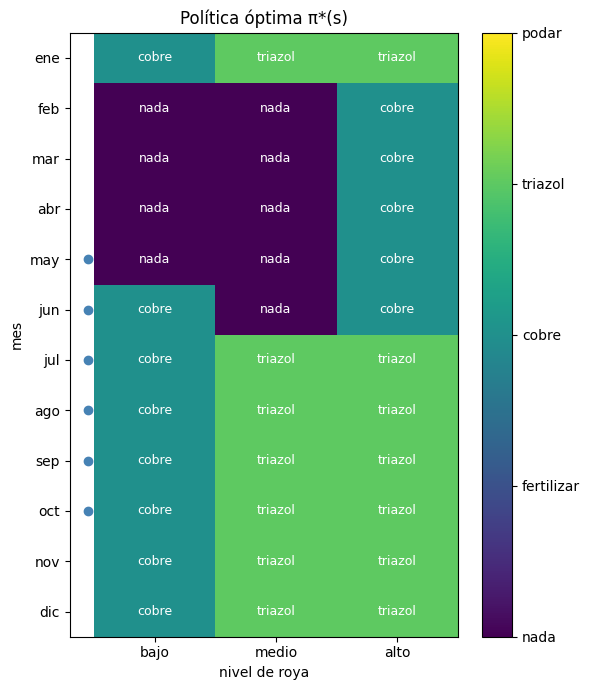

In [5]:
fig, ax = plt.subplots(figsize=(6, 7))
im = ax.imshow(policy_mat, cmap='viridis', aspect='auto', vmin=0, vmax=N_ACTIONS - 1)
ax.set_xticks(range(3), [f'{r}' for r in RUST_NAMES])
ax.set_yticks(range(12), list(MONTH_NAMES))
ax.set_xlabel('nivel de roya')
ax.set_ylabel('mes')
ax.set_title('Política óptima π*(s)')
for m in range(12):
    for r in range(3):
        ax.text(r, m, ACTION_NAMES[policy_mat[m, r]], ha='center', va='center', color='white', fontsize=9)
    if (m + 1) in WET_MONTHS:
        ax.plot(-0.55, m, marker='o', color='steelblue', clip_on=False)
cbar = plt.colorbar(im, ax=ax, ticks=range(N_ACTIONS))
cbar.ax.set_yticklabels(ACTION_NAMES)
plt.tight_layout()
plt.show()

## 4. Comparación contra baselines de política constante

Cinco baselines: aplicar siempre la misma acción todos los meses. Se calcula V^π por *policy evaluation* (Bellman expectation hasta convergencia).

In [6]:
rows = [{
    'politica': 'π* (óptima)',
    'V_mean': round(float(sol.V.mean()), 2),
    'V_inicial_(ene,bajo)': round(float(sol.V[state_index(1, 0)]), 2),
    'V_peor_estado': round(float(sol.V.min()), 2),
}]
for a in range(N_ACTIONS):
    pi = constant_policy(a, N_STATES)
    V_pi = evaluate_policy(T, R, pi, gamma=params.discount)
    rows.append({
        'politica': f'siempre {ACTION_NAMES[a]}',
        'V_mean': round(float(V_pi.mean()), 2),
        'V_inicial_(ene,bajo)': round(float(V_pi[state_index(1, 0)]), 2),
        'V_peor_estado': round(float(V_pi.min()), 2),
    })
bench = pd.DataFrame(rows)
best_baseline = bench.iloc[1:].sort_values('V_mean', ascending=False).iloc[0]
bench['delta_pct_vs_optima'] = ((bench['V_mean'] / float(sol.V.mean())) - 1) * 100
bench

,politica,V_mean,"V_inicial_(ene,bajo)",V_peor_estado,delta_pct_vs_optima
0,π* (óptima),7155.40,7298.05,5917.48,0.000020
1,siempre nada,4350.50,4972.54,3222.82,-39.199753
2,siempre fertilizar,3824.65,4369.68,2677.47,-46.548750
3,siempre cobre,6569.99,6833.95,5422.72,-8.181356
4,siempre triazol,6287.81,6348.75,5042.32,-12.124951
5,siempre podar,5294.52,5447.61,4119.33,-26.006638


In [7]:
gap = (float(sol.V.mean()) - best_baseline['V_mean']) / best_baseline['V_mean'] * 100
print(f'Mejor baseline:  {best_baseline["politica"]:25s}  V_mean = {best_baseline["V_mean"]:.2f}')
print(f'Política óptima: V_mean = {sol.V.mean():.2f}')
print(f'Mejora vs mejor baseline: +{gap:.2f}%')

Mejor baseline:  siempre cobre              V_mean = 6569.99
Política óptima: V_mean = 7155.40
Mejora vs mejor baseline: +8.91%


## 5. Sensibilidad al descuento γ

In [8]:
rows = []
for g in [0.80, 0.90, 0.95, 0.99]:
    s = value_iteration(T, R, gamma=g, tol=1e-3)
    n_actions_used = len(set(s.policy.tolist()))
    rows.append({
        'gamma': g, 'iter': s.iterations,
        'V_mean': round(float(s.V.mean()), 2),
        'acciones_distintas': n_actions_used,
    })
pd.DataFrame(rows)

,gamma,iter,V_mean,acciones_distintas
0,0.80,63,1670.01,3
1,0.90,132,3491.99,3
2,0.95,270,7155.40,3
3,0.99,1370,36528.27,3
